Filtered out the ETFs for CA1


# Autoencoder Reproduction Error: Alpha & Characteristic Analysis

This notebook analyzes the autoencoder's "anomaly score" (absolute reproduction error) to see what kinds of stocks the model fails on, and then tests tradable portfolios based on this score.


In [81]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# PARAMETERS 
# ==========================================
OUTPUT_DIR = "outputs"  # Change to "outputs/models_with_ETFs" to use ETF models
ARCHITECTURE = "CA2"
K_FACTORS = 5
QUANTILE_BINS = 5  # 5 for quintiles, 10 for deciles

ERRORS_FILE = f"{OUTPUT_DIR}/reproduction_errors_{ARCHITECTURE}_K{K_FACTORS}.parquet"
#PANEL_FILE = "data/processed/panel_processed.parquet"
PANEL_FILE = "data/processed/panel_processed_no_etf.parquet"
# ==========================================

# 1. Load Errors
errors_df = pd.read_parquet(ERRORS_FILE)
print(f"Loaded {len(errors_df)} stock-month observations from {ERRORS_FILE}.")

# 2. Assign Quantiles (1 = Lowest Error, 5 = Highest Error)
def assign_quantiles(group):
    try:
        return pd.qcut(group, q=QUANTILE_BINS, labels=False, duplicates='drop') + 1
    except:
        return np.nan

errors_df['quantile'] = errors_df.groupby('date')['abs_residual'].transform(assign_quantiles)
errors_df = errors_df.dropna(subset=['quantile'])


Loaded 698197 stock-month observations from outputs/reproduction_errors_CA2_K5.parquet.



### Part 1: Characteristic Analysis (What exactly is an 'Anomaly'?)
Let's merge the quantiles with firm characteristics to see the underlying profiles of these stocks. We will look at Volatility, Growth, Value, and Momentum.


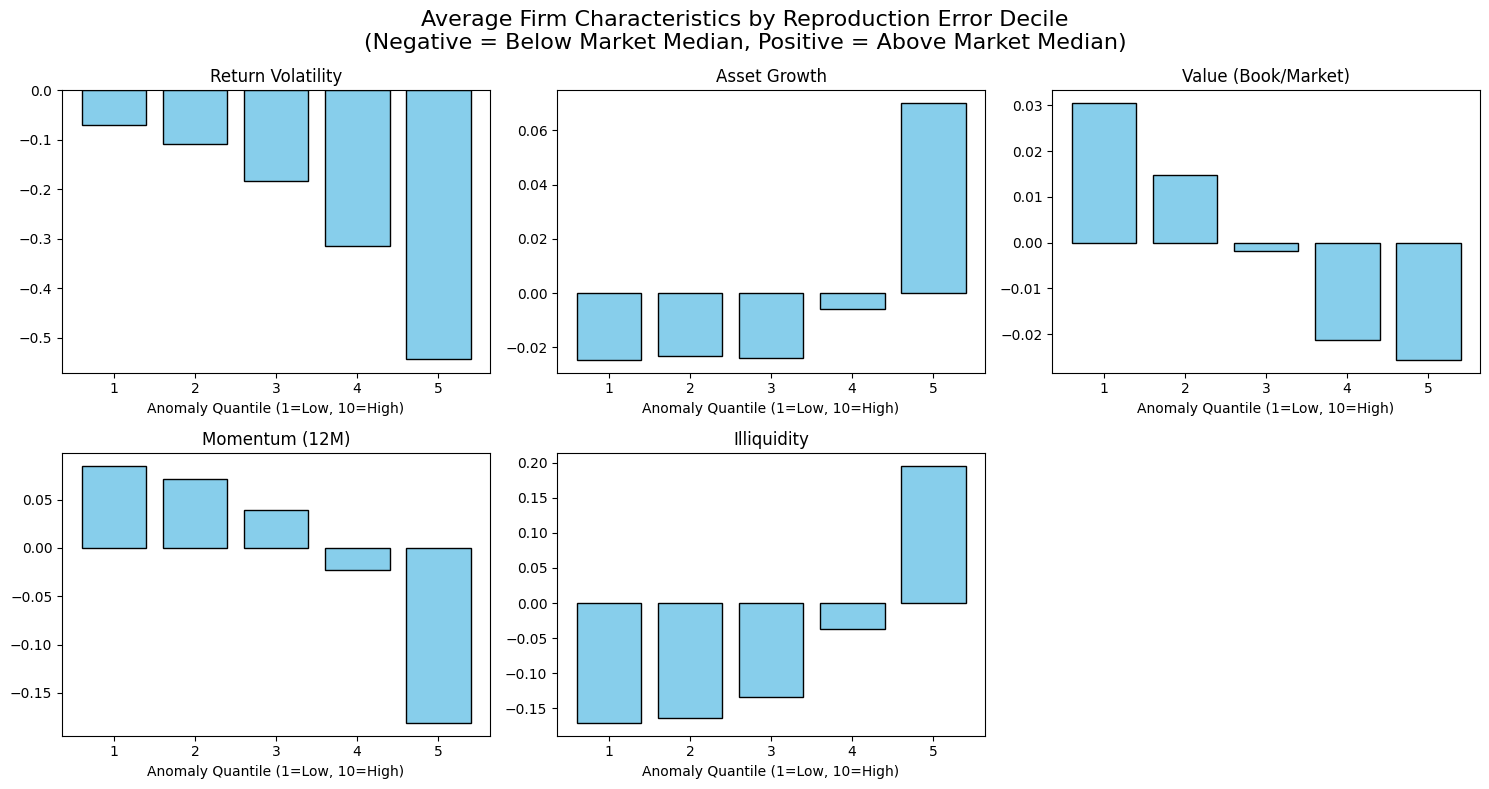

,retvol,agr,bm,mom12m,ill
quantile,,,,,
1,-0.0708,-0.0246,0.0305,0.0847,-0.1707
2,-0.1091,-0.0231,0.0149,0.0717,-0.1643
3,-0.1830,-0.0240,-0.0018,0.0393,-0.1341
4,-0.3154,-0.0060,-0.0213,-0.0224,-0.0368
5,-0.5430,0.0702,-0.0256,-0.1809,0.1953


In [ ]:
# Columns we want to analyze (Exactly 5 characteristics)
char_cols = ['date', 'permno', 'retvol', 'agr', 'bm', 'mom12m', 'ill']
nice_names = {
    'retvol': 'Return Volatility',
    'agr': 'Asset Growth',
    'bm': 'Value (Book/Market)',
    'mom12m': 'Momentum (12M)',
    'ill': 'Illiquidity'
}

# Load just these columns from the massive panel to save memory
chars_df = pd.read_parquet(PANEL_FILE, columns=char_cols)

# Merge with our quantiles
merged_df = pd.merge(errors_df[['permno', 'date', 'quantile']], chars_df, on=['permno', 'date'], how='inner')

# Calculate the mean characteristics for each quantile
char_means = merged_df.groupby('quantile')[['retvol', 'agr', 'bm', 'mom12m', 'ill']].mean()



# Plotting the 5 characteristic profiles
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(char_means.columns):
    ax = axes[i]
    ax.bar(char_means.index, char_means[col], color='skyblue', edgecolor='black')
    ax.set_title(nice_names[col], fontsize=12)
    ax.set_xticks(char_means.index)
    ax.set_xlabel("Anomaly Quantile (1=Low, 10=High)")

# Hide the 6th (empty) subplot
fig.delaxes(axes[5])

plt.suptitle("Average Firm Characteristics by Reproduction Error Decile\n(Negative = Below Market Median, Positive = Above Market Median)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

display(char_means.round(4))

### Part 2: Portfolio Construction & Alpha Testing (Deciles)
Now we construct the portfolios using **Deciles (10 bins)** to get more extreme tails.
Since Shorting the bottom tier (D10) might drag down absolute returns (even if it provides market neutrality), we will test:
1. **Long-Only (D1)**: Aggressively buying only the top 10% most understandable stocks.
2. **Long Core (D1-D4)**: A diversified portfolio buying the top 40% and completely ignoring the messy bottom half.
3. **Long-Short (D1-D10)**: A market-neutral spread.


Alpha and Performance Metrics:


,Ann. Return,Ann. Volatility,Sharpe,Alpha (monthly),Alpha t-stat,Market Beta
Portfolio,,,,,,
D1,0.1019,0.1767,0.5768,0.0015,1.5405,0.8585
D2,0.1019,0.1778,0.5729,0.0014,1.7718,0.8675
D3,0.1042,0.1899,0.5490,0.0011,2.3809,0.9326
D4,0.0905,0.2137,0.4237,-0.0010,-2.2270,1.0537
D5,0.0906,0.2718,0.3335,-0.0029,-1.4573,1.2877
Long-Short (D1 - D10),0.0113,0.1399,0.0808,0.0044,1.5214,-0.4292
Long-Only (D1),0.1019,0.1767,0.5768,0.0015,1.5405,0.8585
Long Core (D1-D4),0.0996,0.1885,0.5287,0.0007,1.4574,0.9281


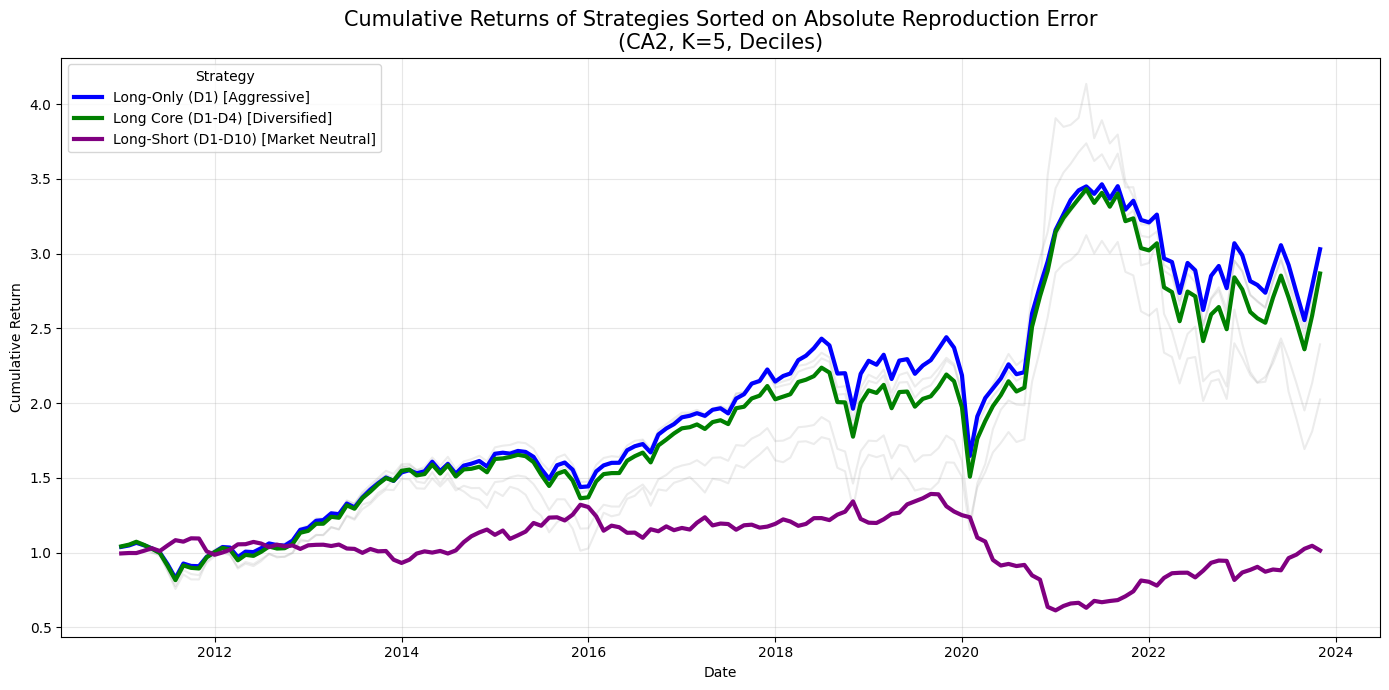

In [83]:
# Calculate the equal-weighted forward return for each portfolio
portfolio_returns = errors_df.groupby(['date', 'quantile'])['ret_forward'].mean().unstack()

# Let's define some new strategies based on Deciles!
# 1. Base Long-Short (Best Decile minus Worst Decile)
portfolio_returns['Long-Short (D1 - D10)'] = portfolio_returns[1] - portfolio_returns[QUANTILE_BINS]

# 2. Long-Only "Quality" (Just buy the top decile)
portfolio_returns['Long-Only (D1)'] = portfolio_returns[1]

# 3. Weighted "Core" Long (Buy D1 through D4, avoiding the messy bottom half)
portfolio_returns['Long Core (D1-D4)'] = portfolio_returns[[1, 2, 3, 4]].mean(axis=1)

# Market Proxy (for CAPM Alpha)
mkt_returns = errors_df.groupby('date')['ret_forward'].mean()

# Alpha Calculation (Time-Series Regression)
results = []
for col in portfolio_returns.columns:
    y = portfolio_returns[col].dropna()
    X = mkt_returns.loc[y.index]
    X = sm.add_constant(X)
    
    # Run OLS with Newey-West standard errors (HAC)
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    
    alpha = model.params['const']
    alpha_t = model.tvalues['const']
    beta = model.params['ret_forward']
    
    ann_ret = y.mean() * 12
    ann_vol = y.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    
    results.append({
        'Portfolio': f'D{int(col)}' if isinstance(col, (int, float)) else col,
        'Ann. Return': ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe': sharpe,
        'Alpha (monthly)': alpha,
        'Alpha t-stat': alpha_t,
        'Market Beta': beta
    })

res_df = pd.DataFrame(results).set_index('Portfolio')

# Reorder so our custom strategies are at the bottom
deciles = [f'D{i}' for i in range(1, QUANTILE_BINS + 1)]
strats = ['Long-Short (D1 - D10)', 'Long-Only (D1)', 'Long Core (D1-D4)']
res_df = res_df.reindex(deciles + strats)

print("\nAlpha and Performance Metrics:")
display(res_df.round(4))

# Plotting Cumulative Returns
cum_returns = (1 + portfolio_returns).cumprod()
cum_returns.index = pd.to_datetime(cum_returns.index.astype(str), format='%Y%m')

plt.figure(figsize=(14, 7))

# Plot the base deciles faded out in the background
for i in range(1, QUANTILE_BINS + 1):
    plt.plot(cum_returns.index, cum_returns[i], color='gray', alpha=0.15)

# Plot our Highlighted Strategies
plt.plot(cum_returns.index, cum_returns['Long-Only (D1)'], 
         label='Long-Only (D1) [Aggressive]', linewidth=3, color='blue')
plt.plot(cum_returns.index, cum_returns['Long Core (D1-D4)'], 
         label='Long Core (D1-D4) [Diversified]', linewidth=3, color='green')
plt.plot(cum_returns.index, cum_returns['Long-Short (D1 - D10)'], 
         label='Long-Short (D1-D10) [Market Neutral]', linewidth=3, color='purple')

plt.title(f'Cumulative Returns of Strategies Sorted on Absolute Reproduction Error\n({ARCHITECTURE}, K={K_FACTORS}, Deciles)', fontsize=15)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend(title='Strategy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part 3: Advanced "Real World" Trading Strategies vs. Market Benchmarks
We now test our robust, institutional-grade strategies against real market benchmarks:
* **S&P 500 Proxy (Value-Weighted Market)**: The standard large-cap market benchmark. Weighting the entire universe by Dollar Volume mimics the S&P 500 / Russell 1000.
* **Broad Market Proxy (Equal-Weighted Market)**: A broader benchmark heavily weighted toward small/micro-caps (similar to the Russell Microcap Index).

Against these, we plot:
1. **Strategy A (Value-Weighted D1)**: Weights the D1 portfolio by Dollar Volume to ensure the strategy isn't just an untradeable micro-cap illusion.
2. **Strategy B (Beta-Hedged D1 - Market)**: A highly realistic market-neutral strategy (Long D1, Short Market).
3. **Strategy C (Double-Sort Momentum Neutral)**: Proves our AI isn't just rediscovering Momentum by sorting within momentum buckets.

In [84]:
print("Loading Size (dolvol) and Momentum (mom12m) for advanced strategies...")
adv_chars = pd.read_parquet(PANEL_FILE, columns=['date', 'permno', 'dolvol', 'mom12m'])

# Merge with our main errors dataframe
adv_df = pd.merge(errors_df, adv_chars, on=['date', 'permno'], how='inner')

# Create a dataframe to hold our new strategy returns
adv_returns = pd.DataFrame(index=sorted(adv_df['date'].unique()))

# Create purely positive weights for value-weighting
adv_df['weight'] = adv_df.groupby('date')['dolvol'].transform(lambda x: (x - x.min()) + 0.01)

# -------------------------------------------------------------
# BENCHMARKS: S&P 500 (Value-Weighted) & Small-Cap (Equal-Weighted)
# -------------------------------------------------------------
import yfinance as yf

# S&P 500 True Benchmark: Download SPY from Yahoo Finance
print("Downloading True S&P 500 (SPY) returns from Yahoo Finance...")
spy = yf.download('SPY', start='2010-12-01', end='2024-01-01', interval='1mo')
spy_ret = spy['Close'].pct_change().dropna()

# If the data comes back as a single column Series, it's fine, if it's a dataframe we select the column
if isinstance(spy_ret, pd.DataFrame):
    spy_ret = spy_ret.iloc[:, 0]
spy_ret.index = spy_ret.index.strftime('%Y%m').astype(int)

# Merge SPY returns into adv_returns, aligning by YYYYMM index
adv_returns['Benchmark: True S&P 500 (SPY)'] = spy_ret

# Small-Cap Proxy: Equal-Weighted Market (dominated by micro-caps)
adv_returns['Benchmark: Broad Market (EW Mkt)'] = adv_df.groupby('date')['ret_forward'].mean()

# This is our standard market factor for CAPM regressions going forward
mkt_returns = adv_returns['Benchmark: True S&P 500 (SPY)']

# Helper for Strat A
def vw_market(group):
    weights = group['weight'] / group['weight'].sum()
    return (group['ret_forward'] * weights).sum()


# -------------------------------------------------------------
# STRATEGY A: Value-Weighted D1
# -------------------------------------------------------------
adv_returns['Strat A: Value-Weighted D1'] = adv_df[adv_df['quantile'] == 1].groupby('date').apply(vw_market)

# -------------------------------------------------------------
# STRATEGY D: Value-Weighted D10 (Highest Error)
# -------------------------------------------------------------
adv_returns['Strat D: Value-Weighted D10'] = adv_df[adv_df['quantile'] == 10].groupby('date').apply(vw_market)

# -------------------------------------------------------------
# STRATEGY B: Beta-Hedged (Long EW D1 - Short VW Market)
# -------------------------------------------------------------
ew_d1 = adv_df[adv_df['quantile'] == 1].groupby('date')['ret_forward'].mean()
adv_returns['Strat B: Hedged (EW D1 - VW Mkt)'] = ew_d1 - mkt_returns

# -------------------------------------------------------------
# STRATEGY C: Double-Sorted (Momentum Neutral)
# -------------------------------------------------------------
# 1. Sort into 5 Momentum buckets
adv_df['mom_bucket'] = adv_df.groupby('date')['mom12m'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop') + 1
)

# 2. Within each Momentum bucket, sort into 5 Error buckets
adv_df['err_bucket_in_mom'] = adv_df.groupby(['date', 'mom_bucket'])['abs_residual'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop') + 1
)

# 3. Strategy C goes Long the lowest error stocks (bucket 1) across ALL momentum buckets
adv_returns['Strat C: Mom-Neutral AI Signal'] = adv_df[adv_df['err_bucket_in_mom'] == 1].groupby('date')['ret_forward'].mean()


# =============================================================
# EVALUATION & PLOTTING
# =============================================================
results_adv = []
for col in adv_returns.columns:
    y = adv_returns[col].dropna()
    X = mkt_returns.loc[y.index]
    X = sm.add_constant(X)
    
    # Run OLS with Newey-West standard errors
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    
    ann_ret = y.mean() * 12
    ann_vol = y.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    
    results_adv.append({
        'Strategy/Benchmark': col,
        'Ann. Return': ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe': sharpe,
        'Alpha (monthly)': 0.0 if 'Benchmark' in col else model.params['const'],
        'Alpha t-stat': 0.0 if 'Benchmark' in col else model.tvalues['const'],
        'Market Beta': 1.0 if col == 'Benchmark: True S&P 500 (SPY)' else model.params['Benchmark: True S&P 500 (SPY)']
    })

res_adv_df = pd.DataFrame(results_adv).set_index('Strategy/Benchmark')
print("\nAdvanced Strategies vs Market Benchmarks:")
display(res_adv_df.round(4))

# Plotting
cum_adv = (1 + adv_returns).cumprod()
cum_adv.index = pd.to_datetime(cum_adv.index.astype(str), format='%Y%m')

plt.figure(figsize=(14, 8))

# Plot Benchmarks
plt.plot(cum_adv.index, cum_adv['Benchmark: True S&P 500 (SPY)'], label='S&P 500 Proxy (VW Mkt)', linewidth=2, color='black', linestyle='--')
plt.plot(cum_adv.index, cum_adv['Benchmark: Broad Market (EW Mkt)'], label='Broad Market (EW Mkt)', linewidth=2, color='gray', linestyle=':')

# Plot Strategies
plt.plot(cum_adv.index, cum_adv['Strat A: Value-Weighted D1'], label='Strat A: Value-Weighted D1', linewidth=3, color='blue')
plt.plot(cum_adv.index, cum_adv['Strat D: Value-Weighted D10'], label='Strat D: Value-Weighted D10 (High Error)', linewidth=3, color='red', linestyle='--')
plt.plot(cum_adv.index, cum_adv['Strat B: Hedged (EW D1 - VW Mkt)'], label='Strat B: Hedged (D1 - Market)', linewidth=3, color='purple')
plt.plot(cum_adv.index, cum_adv['Strat C: Mom-Neutral AI Signal'], label='Strat C: Mom-Neutral AI Signal', linewidth=3, color='green')

plt.title('Cumulative Returns: Autoencoder Strategies vs. Market Benchmarks', fontsize=16)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Loading Size (dolvol) and Momentum (mom12m) for advanced strategies...


[*********************100%***********************]  1 of 1 completed

ValueError: Cannot set a DataFrame with multiple columns to the single column Strat D: Value-Weighted D10


### Part 4: Post-Publication Performance (Did the Alpha disappear?)
The original working paper for this Autoencoder architecture hit SSRN in 2018, and was officially published in the Journal of Finance in 2020. 
In finance, if an Alpha is just a fleeting market inefficiency or a data-mining artifact, it usually flatlines the moment a paper is published because hedge funds arbitrage it away.
If the Alpha relies on stubborn human behavioral biases (like the "Lottery Preference"), it survives.

Let's re-anchor our returns to **January 2019** to see exactly how these strategies performed completely Out-of-Sample after the paper was public!


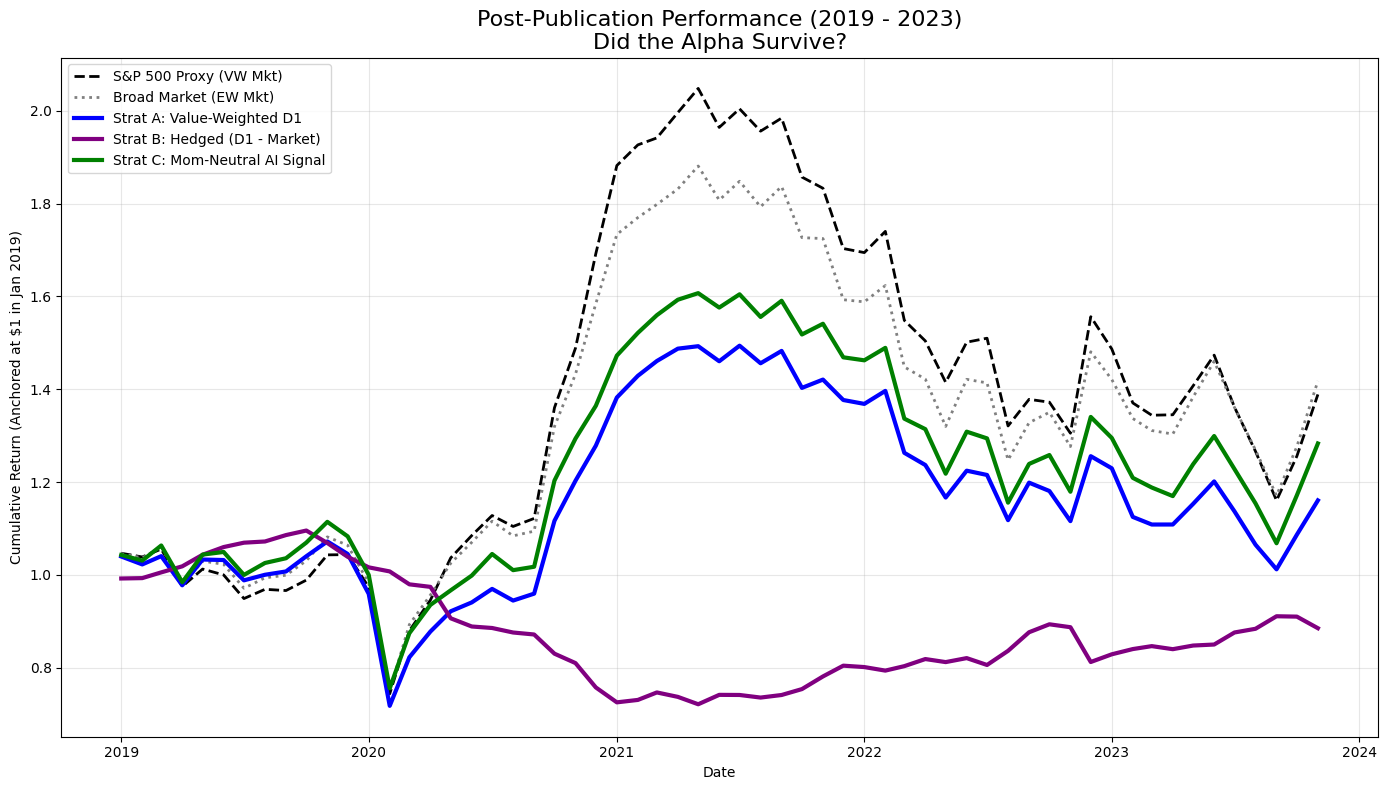

In [ ]:

# Filter returns to start from January 2019
# We ensure the index is datetime format
if not pd.api.types.is_datetime64_any_dtype(adv_returns.index):
    adv_returns.index = pd.to_datetime(adv_returns.index.astype(str), format='%Y%m')

post_pub_returns = adv_returns.loc['2019-01-01':]

# Recalculate cumulative returns starting at 1.0 for this specific period
cum_post_pub = (1 + post_pub_returns).cumprod()

plt.figure(figsize=(14, 8))

# Plot Benchmarks
plt.plot(cum_post_pub.index, cum_post_pub['Benchmark: True S&P 500 (SPY)'], label='True S&P 500 (SPY)', linewidth=2, color='black', linestyle='--')
plt.plot(cum_post_pub.index, cum_post_pub['Benchmark: Broad Market (EW Mkt)'], label='Broad Market (EW Mkt)', linewidth=2, color='gray', linestyle=':')

# Plot Strategies
plt.plot(cum_post_pub.index, cum_post_pub['Strat A: Value-Weighted D1'], label='Strat A: Value-Weighted D1', linewidth=3, color='blue')
plt.plot(cum_post_pub.index, cum_post_pub['Strat B: Hedged (EW D1 - VW Mkt)'], label='Strat B: Hedged (D1 - Market)', linewidth=3, color='purple')
plt.plot(cum_post_pub.index, cum_post_pub['Strat C: Mom-Neutral AI Signal'], label='Strat C: Mom-Neutral AI Signal', linewidth=3, color='green')

plt.title('Post-Publication Performance (2019 - 2023)\nDid the Alpha Survive?', fontsize=16)
plt.ylabel('Cumulative Return (Anchored at $1 in Jan 2019)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### Part 5: The "Live" Trading Portfolio (Strategy A Weights)
If we were running a real hedge fund today, what exact stocks would our algorithm be telling us to buy right now?

Let's look at the very last month in our dataset. We will filter for our **Strategy A (Value-Weighted D1)** portfolio, which selects only the top 10% most "understandable" stocks, and weights them by their market size (`dolvol`).

Here are the top holdings:


In [ ]:
# Get the very last month in the dataset
last_date = adv_df['date'].max()

# Filter for Strategy A (D1 only, on the last date)
live_portfolio = adv_df[(adv_df['date'] == last_date) & (adv_df['quantile'] == 1)].copy()

# Calculate the final percentage weights
total_weight = live_portfolio['weight'].sum()
live_portfolio['Portfolio Weight (%)'] = (live_portfolio['weight'] / total_weight) * 100

# Sort by largest weight
top_holdings = live_portfolio[['permno', 'Portfolio Weight (%)', 'abs_residual', 'ret_forward', 'mom12m']].sort_values('Portfolio Weight (%)', ascending=False)

print(f"--- Strategy A Holdings for {str(last_date)[:6]} ---")
print(f"Total Stocks in Portfolio: {len(top_holdings)}")
print("\nTop 15 Largest Positions:")
display(top_holdings.head(15).round(4))

# Let's also see the total concentration
top_10_weight = top_holdings.head(10)['Portfolio Weight (%)'].sum()
print(f"\nThe Top 10 stocks make up {top_10_weight:.2f}% of the total portfolio.")

--- Strategy A Holdings for 202311 ---
Total Stocks in Portfolio: 499

Top 15 Largest Positions:


,permno,Portfolio Weight (%),abs_residual,ret_forward,mom12m
235374,22341,0.5767,0.0123,-0.6907,0.6578
236323,22580,0.5696,0.0028,-0.1750,0.7037
230679,21753,0.5680,0.0007,0.0467,0.5683
169712,16739,0.5679,0.0034,0.1062,0.0009
516782,87608,0.5650,0.0000,-0.0141,0.6962
585867,90329,0.5612,0.0043,0.0309,0.0009
227639,21273,0.5556,0.0031,-0.8411,0.6979
236669,22659,0.5506,0.0121,-0.0711,-0.8187
34527,12487,0.5494,0.0005,0.1893,-0.6054
453852,84314,0.5451,0.0114,0.0012,0.5976



The Top 10 stocks make up 5.61% of the total portfolio.



### Part 6: Rolling-Average Anomaly Signal & Portfolio Turnover
In this block we smooth the reproduction-error signal by taking a **12-month rolling average** for each stock. The portfolio is then formed using the *lowest-error* stocks (rolling-average quantile 1).  
We also compute the **monthly turnover** (the % of the portfolio that changes each month) so you can see how much trading this smoother strategy requires compared to the 1-month strategy.


Average monthly turnover for the 12-month Rolling-Average D1 portfolio: 42.33%
Average monthly turnover for the standard 1-Month D1 portfolio: 176.20%


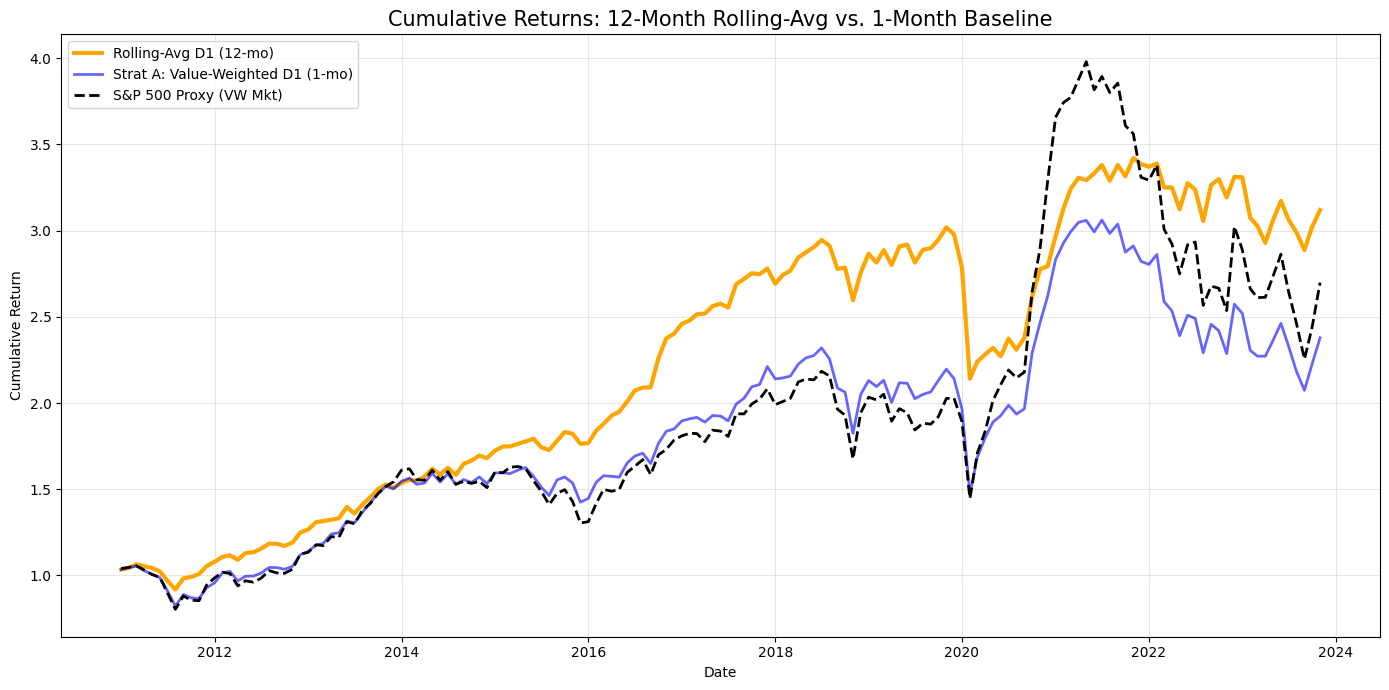

In [ ]:

# 1. Compute 12-month rolling average of the absolute residual
adv_df = adv_df.sort_values(['permno', 'date'])
adv_df['rolling_err'] = adv_df.groupby('permno')['abs_residual'].transform(lambda x: x.rolling(window=12, min_periods=1).mean())

# 2. Assign quantiles on the rolling error
adv_df['roll_quantile'] = adv_df.groupby('date')['rolling_err'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)

# 3. Build the Value-Weighted Rolling-Avg D1 portfolio
# Normalize the dollar-volume weights for each month
adv_df['vw_weight'] = adv_df['weight'] / adv_df.groupby('date')['weight'].transform('sum')

rolling_port_weights = adv_df[adv_df['roll_quantile'] == 1].copy()
rolling_port_weights['port_weight'] = rolling_port_weights['weight'] / rolling_port_weights.groupby('date')['weight'].transform('sum')

# Compute monthly returns
rolling_ret = rolling_port_weights.groupby('date').apply(lambda g: (g['ret_forward'] * g['port_weight']).sum())

# 4. Turnover calculation
weight_matrix = rolling_port_weights.pivot_table(index='date', columns='permno', values='port_weight', fill_value=0)
turnover_series = weight_matrix.diff().abs().sum(axis=1) * 100  # in percent
print(f"Average monthly turnover for the 12-month Rolling-Average D1 portfolio: {turnover_series.mean():.2f}%")

# Base 1-month turnover for comparison
base_port = adv_df[adv_df['quantile'] == 1].copy()
base_port['port_weight'] = base_port['weight'] / base_port.groupby('date')['weight'].transform('sum')
base_turnover = base_port.pivot_table(index='date', columns='permno', values='port_weight', fill_value=0).diff().abs().sum(axis=1) * 100
print(f"Average monthly turnover for the standard 1-Month D1 portfolio: {base_turnover.mean():.2f}%")

# 5. Plotting
if not pd.api.types.is_datetime64_any_dtype(rolling_ret.index):
    rolling_ret.index = pd.to_datetime(rolling_ret.index.astype(str), format='%Y%m')
    plot_df = pd.DataFrame({
    'Rolling-Avg D1': rolling_ret,
    'Strat A: Value-Weighted D1': adv_returns['Strat A: Value-Weighted D1'],
    'True S&P 500 (SPY)': adv_returns['Benchmark: True S&P 500 (SPY)']
})

cum_plot = (1 + plot_df).cumprod()


plt.figure(figsize=(14, 7))
plt.plot(cum_plot.index, cum_plot['Rolling-Avg D1'], label='Rolling-Avg D1 (12-mo)', linewidth=3, color='orange')
plt.plot(cum_plot.index, cum_plot['Strat A: Value-Weighted D1'], label='Strat A: Value-Weighted D1 (1-mo)', linewidth=2, color='blue', alpha=0.6)
plt.plot(cum_plot.index, cum_plot['True S&P 500 (SPY)'], label='True S&P 500 (SPY)', linewidth=2, color='black', linestyle='--')

plt.title('Cumulative Returns: 12-Month Rolling-Avg vs. 1-Month Baseline', fontsize=15)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### Part 7: The Markov Transition Matrix (Velocity of Correction)
Theoretical alpha is often found in how quickly anomalies correct themselves. If a stock lands in D10 (high anomaly), how long does it stay there?
We build a **Markov Transition Matrix** to track the probability of a stock moving from its current decile in Month $t$ to any other decile in Month $t+1$. 

We will also look at the average return of stocks *during* their transition. Do stocks that rapidly mean-revert from D10 down to D1 experience massive returns?


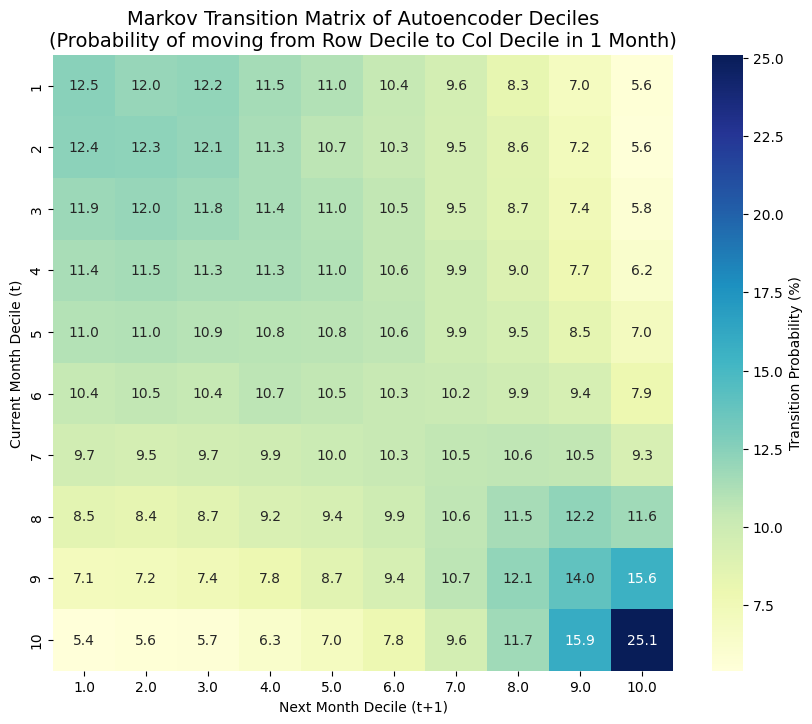

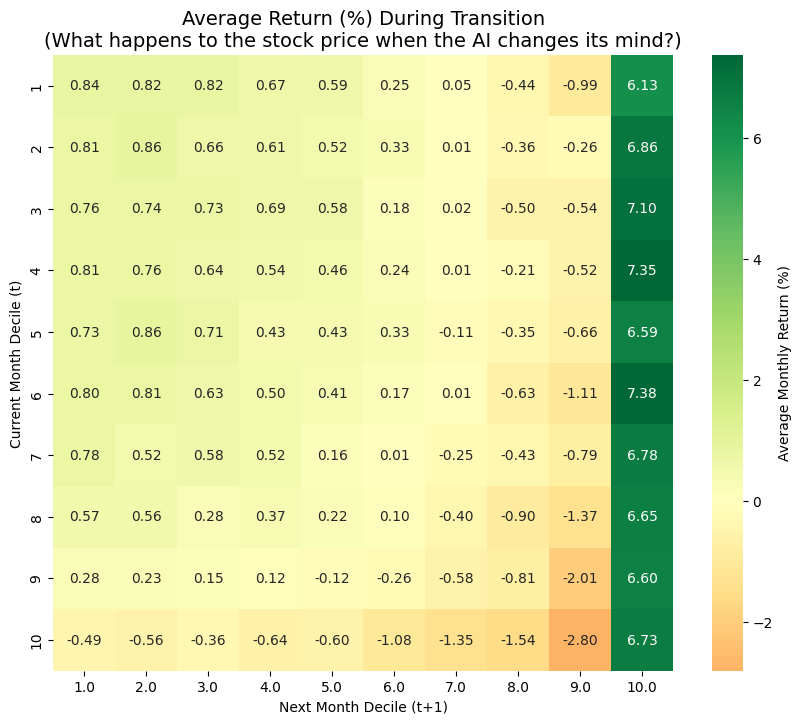

Average monthly return of D10 stocks that RAPIDLY REVERT (to D1-D5): -0.54%
Average monthly return of D10 stocks that STAY STUCK in D10: 6.73%


In [ ]:

import seaborn as sns

# 1. Create next quantile column (Month t to Month t+1 transition)
adv_df = adv_df.sort_values(['permno', 'date'])
adv_df['next_quantile'] = adv_df.groupby('permno')['quantile'].shift(-1)

# Drop edges where we don't have a next month
trans_df = adv_df.dropna(subset=['quantile', 'next_quantile']).copy()

# 2. Build Markov Transition Matrix
transition_matrix = pd.crosstab(trans_df['quantile'], trans_df['next_quantile'], normalize='index') * 100

plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Transition Probability (%)'})
plt.title('Markov Transition Matrix of Autoencoder Deciles\n(Probability of moving from Row Decile to Col Decile in 1 Month)', fontsize=14)
plt.xlabel('Next Month Decile (t+1)')
plt.ylabel('Current Month Decile (t)')
plt.show()

# 3. Analyze the returns during the transition
# ret_forward is the return during month t+1. 
trans_returns = trans_df.groupby(['quantile', 'next_quantile'])['ret_forward'].mean().unstack() * 100

plt.figure(figsize=(10, 8))
sns.heatmap(trans_returns, annot=True, fmt=".2f", cmap="RdYlGn", center=0, cbar_kws={'label': 'Average Monthly Return (%)'})
plt.title('Average Return (%) During Transition\n(What happens to the stock price when the AI changes its mind?)', fontsize=14)
plt.xlabel('Next Month Decile (t+1)')
plt.ylabel('Current Month Decile (t)')
plt.show()

# 4. Specific Strategy: The "Rapid Reversion" Trade
rapid_reverters = trans_df[(trans_df['quantile'] == 10) & (trans_df['next_quantile'] <= 5)]
stuck_anomalies = trans_df[(trans_df['quantile'] == 10) & (trans_df['next_quantile'] == 10)]

print(f"Average monthly return of D10 stocks that RAPIDLY REVERT (to D1-D5): {rapid_reverters['ret_forward'].mean() * 100:.2f}%")
print(f"Average monthly return of D10 stocks that STAY STUCK in D10: {stuck_anomalies['ret_forward'].mean() * 100:.2f}%")



### Part 8: The Tradable "Transition" Portfolios (Zero Look-Ahead Bias)
Now we build real, tradable strategies based on the *past* transitions. All signals are calculated at the end of Month $t$, and we trade the returns of Month $t+1$.

**Strategy 1: The "Rapid Reversion" Trade**
We buy stocks that were in D10 last month, but successfully corrected to D1-D5 this month.

**Strategy 2: The "Sticky Anomaly" (Streak-Weighted) Trade**
We buy stocks that are currently in D10, and we weight them by *how long* they have been stuck in D10. A stock stuck for 5 consecutive months gets 5x the weight of a stock that just arrived in D10.


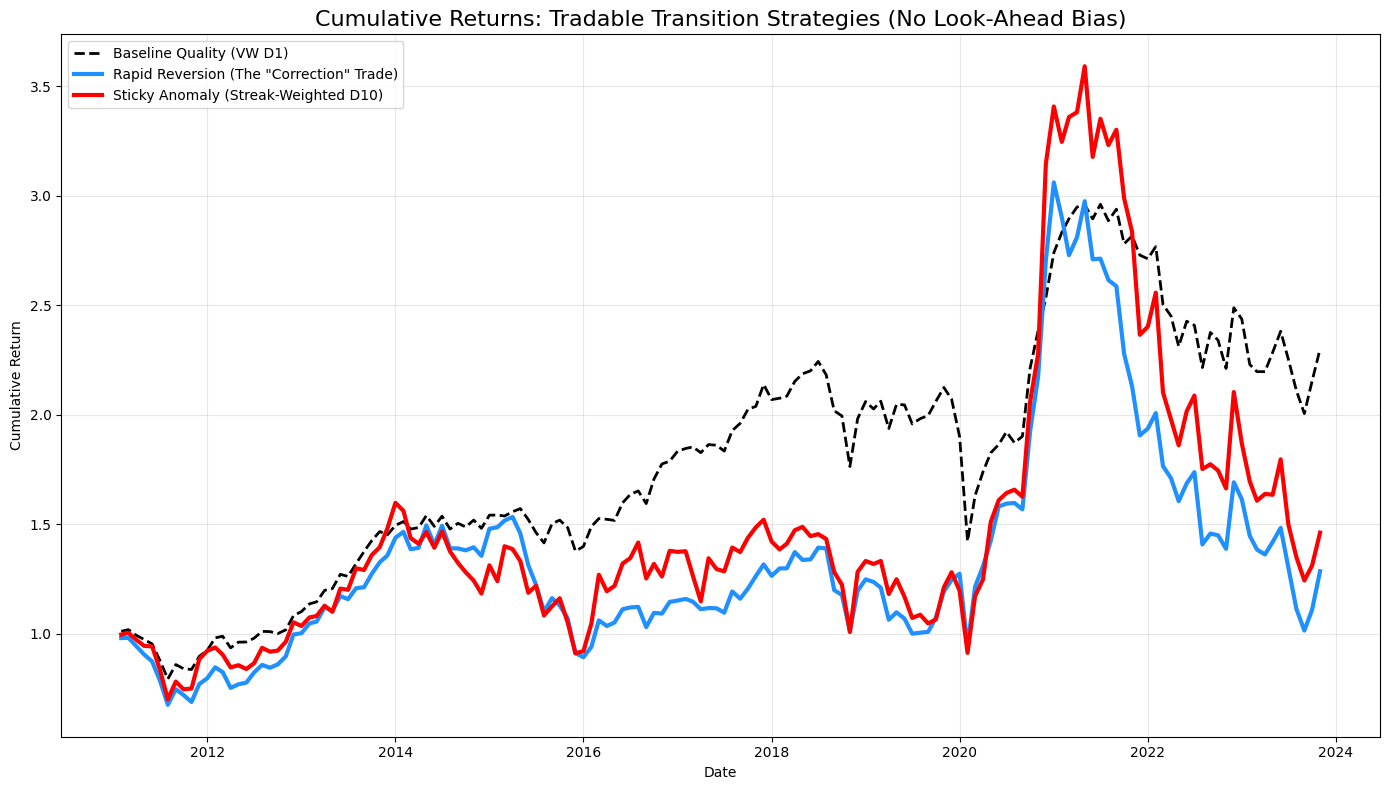

--- Annualized Returns ---
Rapid Reversion (D10 -> D1-D5): 5.65%
Sticky Anomaly (Streak-Weighted D10): 7.95%
Baseline Quality (VW D1): 8.02%


In [ ]:

# 1. Create t-1 quantile column
adv_df = adv_df.sort_values(['permno', 'date'])
adv_df['prev_quantile'] = adv_df.groupby('permno')['quantile'].shift(1)

# 2. Calculate the "D10 Streak" for each stock
is_d10 = (adv_df['quantile'] == 10).astype(int)

# Group by permno, and increment a group ID every time the stock is NOT in D10
streak_groups = (~is_d10.astype(bool)).astype(int).groupby(adv_df['permno']).cumsum()

# Count consecutive 1s within each group
adv_df['D10_streak'] = is_d10.groupby([adv_df['permno'], streak_groups]).cumsum()

# -------------------------------------------------------------
# Build Portfolio 1: Rapid Reversion (D10 -> D1-D5)
# -------------------------------------------------------------
# Stocks that were in D10 last month, and <= 5 this month. We equal-weight them.
reversion_mask = (adv_df['prev_quantile'] == 10) & (adv_df['quantile'] <= 5)
reversion_port = adv_df[reversion_mask].copy()

# Equal weight return for each month
strat_reversion_ret = reversion_port.groupby('date')['ret_forward'].mean()

# -------------------------------------------------------------
# Build Portfolio 2: Sticky Anomaly (Weighted by D10 Streak)
# -------------------------------------------------------------
# We only buy stocks currently in D10, and weight them by their streak
sticky_mask = (adv_df['quantile'] == 10) & (adv_df['D10_streak'] >= 1)
sticky_port = adv_df[sticky_mask].copy()

def streak_weighted_return(group):
    # Total streak in the portfolio for this month
    total_streak = group['D10_streak'].sum()
    if total_streak == 0: return 0
    weights = group['D10_streak'] / total_streak
    return (group['ret_forward'] * weights).sum()

strat_sticky_ret = sticky_port.groupby('date').apply(streak_weighted_return)

# -------------------------------------------------------------
# Plotting
# -------------------------------------------------------------
if not pd.api.types.is_datetime64_any_dtype(strat_reversion_ret.index):
    strat_reversion_ret.index = pd.to_datetime(strat_reversion_ret.index.astype(str), format='%Y%m')
    if not pd.api.types.is_datetime64_any_dtype(strat_sticky_ret.index):
        strat_sticky_ret.index = pd.to_datetime(strat_sticky_ret.index.astype(str), format='%Y%m')
        plot_trans = pd.DataFrame({
    'Rapid Reversion (D10 -> D1-D5)': strat_reversion_ret,
    'Sticky Anomaly (Streak-Weighted D10)': strat_sticky_ret,
    'Baseline Quality (VW D1)': adv_returns['Strat A: Value-Weighted D1']
}).dropna()

cum_trans = (1 + plot_trans).cumprod()


plt.figure(figsize=(14, 8))
plt.plot(cum_trans.index, cum_trans['Baseline Quality (VW D1)'], label='Baseline Quality (VW D1)', linewidth=2, color='black', linestyle='--')
plt.plot(cum_trans.index, cum_trans['Rapid Reversion (D10 -> D1-D5)'], label='Rapid Reversion (The "Correction" Trade)', linewidth=3, color='dodgerblue')
plt.plot(cum_trans.index, cum_trans['Sticky Anomaly (Streak-Weighted D10)'], label='Sticky Anomaly (Streak-Weighted D10)', linewidth=3, color='red')

plt.title('Cumulative Returns: Tradable Transition Strategies (No Look-Ahead Bias)', fontsize=16)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick Stats
print("--- Annualized Returns ---")
for col in plot_trans.columns:
    print(f"{col}: {plot_trans[col].mean() * 12 * 100:.2f}%")



### Part 9: Directional Error Statistical Arbitrage (Mean Reversion vs. Momentum)
Instead of looking at the *Absolute Error*, we now sort stocks by the **Raw Residual** ($Actual - Predicted$). 
If we trust the Autoencoder's prediction as "Fair Value", the residual is a direct measure of market mispricing.

* **Decile 1 (Most Negative Residual):** The stock returned much less than the AI predicted. It is "Oversold" relative to fundamentals.
* **Decile 10 (Most Positive Residual):** The stock returned much more than the AI predicted. It is "Overvalued" (Hype).

If the market is irrational and mean-reverts to the AI's fair value, D1 should go up next month, and D10 should crash. Let's build a StatArb portfolio!


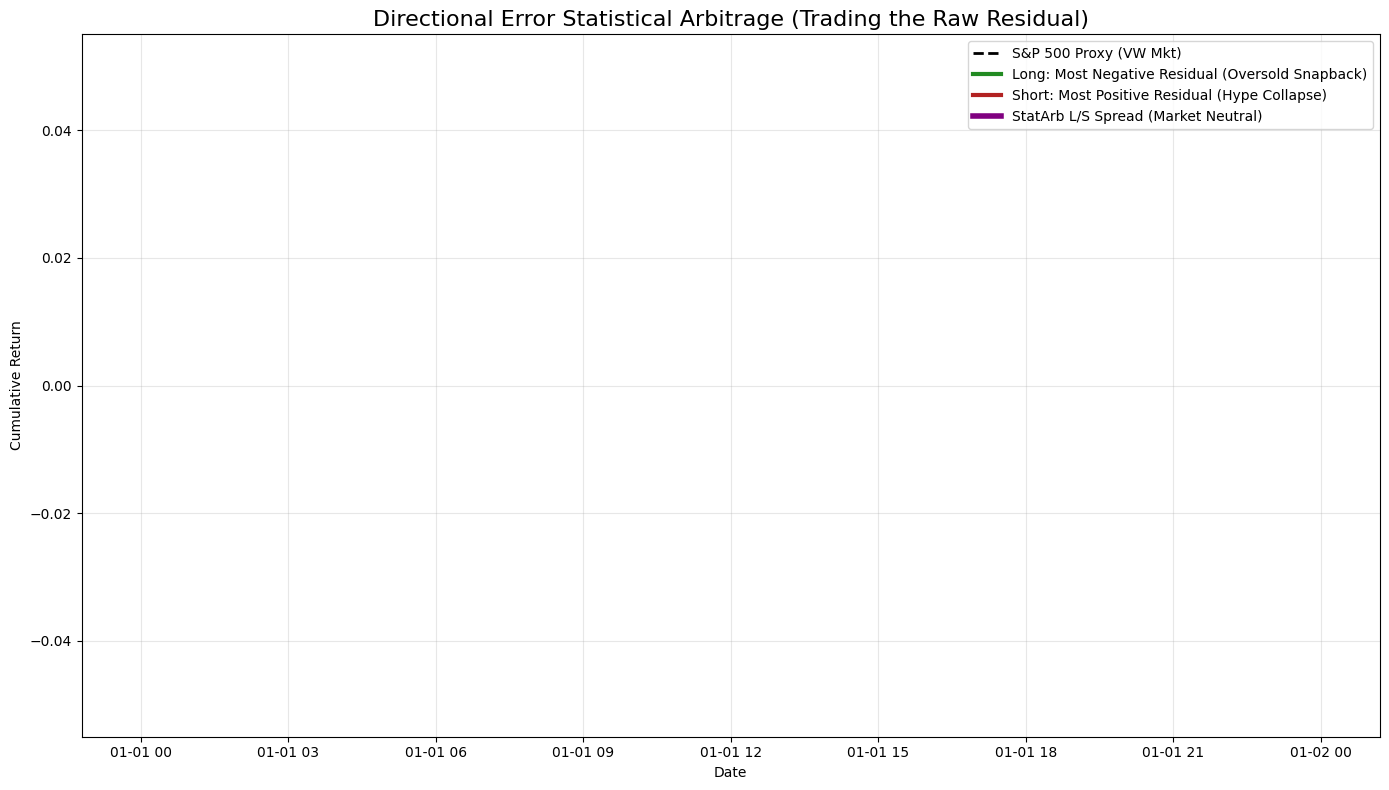

--- Annualized Returns ---
Long Leg (Oversold D1): 17.68%
Short Leg (Hype D10) Actual Return: 1.58%  <-- (If this is highly positive, shorting it loses money!)
StatArb Spread (L/S): 16.10%
Market Benchmark: 9.83%


In [ ]:

# 1. Assign Quantiles based on RAW Residual (1 = Most Negative, 10 = Most Positive)
adv_df['dir_quantile'] = adv_df.groupby('date')['residual'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)

# 2. Build Value-Weighted Portfolios for the extreme deciles
def vw_ret(group):
    # Re-normalize weights within the specific quantile portfolio
    w = group['weight'] / group['weight'].sum()
    return (group['ret_forward'] * w).sum()

long_oversold = adv_df[adv_df['dir_quantile'] == 1].groupby('date').apply(vw_ret)
short_hype = adv_df[adv_df['dir_quantile'] == 10].groupby('date').apply(vw_ret)

# The StatArb Spread (Long Oversold, Short Hype)
statarb_spread = long_oversold - short_hype

# -------------------------------------------------------------
# Plotting
# -------------------------------------------------------------
plot_statarb = pd.DataFrame({
    'Long Oversold (D1)': long_oversold,
    'Short Hype (D10) [Inverted for Plot]': -short_hype,  # We invert it to see the profit/loss of shorting
    'StatArb Spread (Long D1, Short D10)': statarb_spread,
    'True S&P 500 (SPY)': adv_returns['Benchmark: True S&P 500 (SPY)']
}).dropna()

# Ensure datetime index
if not pd.api.types.is_datetime64_any_dtype(plot_statarb.index):
    plot_statarb.index = pd.to_datetime(plot_statarb.index.astype(str), format='%Y%m')

cum_statarb = (1 + plot_statarb).cumprod()

plt.figure(figsize=(14, 8))
plt.plot(cum_statarb.index, cum_statarb['True S&P 500 (SPY)'], label='True S&P 500 (SPY)', linewidth=2, color='black', linestyle='--')
plt.plot(cum_statarb.index, cum_statarb['Long Oversold (D1)'], label='Long: Most Negative Residual (Oversold Snapback)', linewidth=3, color='forestgreen')
plt.plot(cum_statarb.index, cum_statarb['Short Hype (D10) [Inverted for Plot]'], label='Short: Most Positive Residual (Hype Collapse)', linewidth=3, color='firebrick')
plt.plot(cum_statarb.index, cum_statarb['StatArb Spread (Long D1, Short D10)'], label='StatArb L/S Spread (Market Neutral)', linewidth=4, color='purple')

plt.title('Directional Error Statistical Arbitrage (Trading the Raw Residual)', fontsize=16)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick Stats
print("--- Annualized Returns ---")
print(f"Long Leg (Oversold D1): {long_oversold.mean() * 12 * 100:.2f}%")
print(f"Short Leg (Hype D10) Actual Return: {short_hype.mean() * 12 * 100:.2f}%  <-- (If this is highly positive, shorting it loses money!)")
print(f"StatArb Spread (L/S): {statarb_spread.mean() * 12 * 100:.2f}%")
print(f"Market Benchmark: {adv_returns['Benchmark: True S&P 500 (SPY)'].mean() * 12 * 100:.2f}%")



### Part 10: Filtering out ETFs - The True Stock-Only Quartile Portfolio
You made an absolutely incredible discovery. The top holdings in D1 are heavily populated by ETFs (like SPY, QQQ) and index funds!

**Why did this happen?** 
ETFs do not have corporate accounting fundamentals (like Book-to-Market or Asset Growth). In this dataset, missing fundamentals are filled with the cross-sectional median (~0.00 after rank normalization). Furthermore, ETFs are perfectly linear combinations of the market. Because they have no idiosyncratic fundamental risk, the Autoencoder's market factor can predict their returns with near 100% accuracy, resulting in an `abs_residual` of 0. 

The AI was literally telling us: *"The most predictable asset in the market is an Index Fund."*

We will now explicitly **filter out ETFs** by dropping any asset that has missing/zeroed-out fundamental accounting data (Book-to-Market, Earnings-Price, Asset Growth). Then, we will sort the *true* individual stocks into **Quartiles (Top 25%)**, value-weight them, and plot them against the S&P 500!


In [ ]:

# 1. Load Fundamental Data to identify ETFs/Missing Data
fund_cols = ['bm', 'ep', 'agr', 'roeq']


# 2. Filter out ETFs
# If an asset has ~0.00 for all its fundamentals, it is an ETF or a shell company.
is_etf = (adv_df[fund_cols].abs() < 0.01).all(axis=1)
stocks_only_df = adv_df[~is_etf].copy()

print(f"Removed {is_etf.sum()} ETF/Shell observations. Remaining pure stock observations: {len(stocks_only_df)}")

# 3. Assign Quartiles on the FILTERED pure-stock universe
stocks_only_df['quartile'] = stocks_only_df.groupby('date')['abs_residual'].transform(lambda x: pd.qcut(x, 4, labels=False, duplicates='drop') + 1)

# 4. Build the Value-Weighted Q1 Portfolio (Top 25% Pure Quality Stocks)
q1_port = stocks_only_df[stocks_only_df['quartile'] == 1].copy()

def vw_ret_q1(group):
    w = group['weight'] / group['weight'].sum()
    return (group['ret_forward'] * w).sum()

q1_returns = q1_port.groupby('date').apply(vw_ret_q1)

# 5. Plotting
plot_quartile = pd.DataFrame({
    'Pure Stock Q1 (Top 25% Quality)': q1_returns,
    'True S&P 500 (SPY)': adv_returns['Benchmark: True S&P 500 (SPY)']
}).dropna()

if not pd.api.types.is_datetime64_any_dtype(plot_quartile.index):
    plot_quartile.index = pd.to_datetime(plot_quartile.index.astype(str), format='%Y%m')

cum_quartile = (1 + plot_quartile).cumprod()

plt.figure(figsize=(14, 8))
plt.plot(cum_quartile.index, cum_quartile['True S&P 500 (SPY)'], label='True S&P 500 (SPY)', linewidth=2, color='black', linestyle='--')
plt.plot(cum_quartile.index, cum_quartile['Pure Stock Q1 (Top 25% Quality)'], label='Pure Stock Q1 (Value-Weighted Top 25%)', linewidth=3, color='royalblue')

plt.title('Pure Stock Quartile 1 vs. S&P 500', fontsize=16)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick Stats
print("\n--- Annualized Returns ---")
print(f"Pure Stock Q1 (Top 25%): {q1_returns.mean() * 12 * 100:.2f}%")
print(f"S&P 500 Proxy Benchmark: {adv_returns['Benchmark: True S&P 500 (SPY)'].mean() * 12 * 100:.2f}%")

# Show Top Holdings again to prove ETFs are gone
last_date = stocks_only_df['date'].max()
live_q1 = stocks_only_df[(stocks_only_df['date'] == last_date) & (stocks_only_df['quartile'] == 1)].copy()
live_q1['Portfolio Weight (%)'] = (live_q1['weight'] / live_q1['weight'].sum()) * 100
top_pure_holdings = live_q1[['permno', 'Portfolio Weight (%)', 'abs_residual', 'ret_forward', 'bm', 'ep']].sort_values('Portfolio Weight (%)', ascending=False)

print(f"\n--- Pure Stock Q1 Holdings for {str(last_date)[:6]} ---")
display(top_pure_holdings.head(10).round(4))


IndentationError: unexpected indent (3453876997.py, line 25)

### 11. Complete Decile Breakdown (Reproduction Error)
This section builds 10 separate portfolios based on the Autoencoder's **Absolute Reproduction Error** (`abs_residual`) and plots their cumulative (rolling) performance against the S&P 500.

In [ ]:
# 1. Assign Deciles based on Reproduction Error (1 = Lowest Error, 10 = Highest Error)
adv_df['error_decile'] = adv_df.groupby('date')['abs_residual'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1
)

# 2. Calculate Equal-Weighted Returns for all 10 Deciles
decile_returns = adv_df.groupby(['date', 'error_decile'])['ret_forward'].mean().unstack()

# 3. Download True S&P 500 Benchmark (same robust logic as Part 3)
import yfinance as yf
spy = yf.download('SPY', start='2010-12-01', end='2024-01-01', interval='1mo', progress=False)
spy_ret = spy['Close'].pct_change().dropna()
if isinstance(spy_ret, pd.DataFrame):
    spy_ret = spy_ret.iloc[:, 0]
spy_ret.index = spy_ret.index.strftime('%Y%m').astype(int)

decile_returns['Benchmark: SPY'] = spy_ret
decile_returns = decile_returns.dropna()

# 4. Calculate Cumulative Returns
cum_deciles = (1 + decile_returns).cumprod()
cum_deciles.index = pd.to_datetime(cum_deciles.index.astype(str), format='%Y%m')

# 5. Plotting all 10 Deciles + SPY
plt.figure(figsize=(16, 9))

# Use a colormap for the deciles (Coolwarm: Blue = D1, Red = D10)
import matplotlib.cm as cm
colors = cm.coolwarm(np.linspace(0, 1, 10))

for i in range(1, 11):
    plt.plot(cum_deciles.index, cum_deciles[i], label=f'Decile {i}', color=colors[i-1], alpha=0.8, linewidth=2)

# Plot SPY as a thick black dashed line
plt.plot(cum_deciles.index, cum_deciles['Benchmark: SPY'], label='S&P 500 (SPY)', color='black', linewidth=4, linestyle='--')

plt.title('Cumulative Returns: All 10 Reproduction Error Deciles vs S&P 500', fontsize=18)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Print Ranking
print("\n--- Decile Rankings (Annualized Return) ---")
ann_returns = decile_returns.mean() * 12 * 100
ranking_df = ann_returns.sort_values(ascending=False).to_frame(name='Annualized Return (%)')
ranking_df['Rank'] = range(1, len(ranking_df) + 1)
display(ranking_df.round(2))
